# Module 10 - Milestone: TinyLLM

Use this notebook after Module 09B pretraining setup and Module 10 trainer tests are passing. The focus is the first real run: prepare a corpus, train a tiny TransformerLM, track validation loss, and sample from the result. Each training section saves a rolling checkpoint to `data/`, so you can stop a run with Ctrl+C, inspect curves and samples, then re-run the cell to continue from where it left off. When a run looks done, run the **save artifact** cell at the end of its section to publish a durable model artifact under `artifacts/models/` for downstream modules.

1. Read the lesson page (`docs/modules/10-tinyllm.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 10`.
3. Answer the `Question:` / `Answer:` cells below.
4. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [1]:
from __future__ import annotations

import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import g2c
from g2c.artifacts import (
    load_corpus_text,
    load_tinystories_text as load_tinystories_corpus_text,
    load_or_encode_tokenized_corpus,
    load_or_encode_tokenized_pair,
    load_run_state,
    save_model_artifact,
)
from g2c.tokenizer import BPETokenizer
from g2c.pretraining import split_token_stream
from g2c.transformer import TransformerLM
from g2c.notebook_extras.pretraining import (
    make_encode_progress,
    plot_training_history,
    train_with_progress,
)

_ = torch.manual_seed(0)
repo_root = Path(g2c.__file__).resolve().parents[1]
trainer_device = "auto"
print("MPS available:", torch.backends.mps.is_available())

MPS available: True


## Before the Notebook

Module 03B should already provide `AdamW`, `cosine_with_warmup`, and `clip_grad_norm_`. Module 09B should already provide `get_lm_batch` and `lm_cross_entropy`. For Module 10, implement `Trainer.train_step`. The trainer also depends on your completed `TransformerLM` from Module 09.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_training.py -x"
"Then run: .venv/bin/python -m pytest tests/test_pretraining_setup.py -x"
"Then run: .venv/bin/python -m pytest tests/test_pretraining.py -x"
"Question: Which trainer test is the next one failing, and which part of train_step does it point at?"
"Answer: "

'Answer: '

In [3]:
for test_file in ["tests/test_training.py", "tests/test_pretraining_setup.py", "tests/test_pretraining.py"]:
    result = subprocess.run(
        [sys.executable, "-m", "pytest", test_file],
        cwd=repo_root,
        text=True,
        capture_output=True,
    )
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    assert result.returncode == 0, f"{test_file} is not passing yet."

print("Module 03B, Module 09B, and Module 10 tests passed.")

.....................                                                    [100%]
21 passed in 0.49s

..............                                                           [100%]
14 passed in 0.50s

............................                                             [100%]
28 passed in 1.69s

Module 03B, Module 09B, and Module 10 tests passed.


## Reset Training Checkpoints

Run this cell **on demand** to wipe the rolling training checkpoints under `data/`. The training cells below auto-resume from these checkpoints if they exist, so wipe them when you change a model or trainer config and want a fresh run. This cell does **not** touch saved model artifacts under `artifacts/models/`.

Skip this cell during normal Run All -- otherwise you will throw away in-progress training every time.

In [ ]:
rolling_ckpt_pattern = "module10-*.ckpt"
removed = 0
for p in sorted((repo_root / "data").glob(rolling_ckpt_pattern)):
    p.unlink()
    print(f"removed {p.name}")
    removed += 1
if removed == 0:
    print("no rolling checkpoints found")

## Exercise 1 - Prepare TinyShakespeare or Fallback Text

Use the downloaded TinyShakespeare file if setup has it. The fallback keeps the notebook runnable, but TinyShakespeare is the intended starter corpus. Keep this first run small: it proves the trainer works before you spend time on TinyStories.

In [ ]:
text_max_chars = 1_000_000
shakespeare_tokenizer_name = "ShakespeareTokenizer"
# Effective vocab size for this run. None = full tokenizer vocab,
# 0 = byte + reserved special tokens only, N = truncate to merges with ID < N.
# Setting N larger than the tokenizer's trained vocab raises ValueError.
shakespeare_requested_vocab_size = None


def load_pretraining_text(max_chars: int) -> str:
    path = repo_root / "data" / "tinyshakespeare.txt"
    if path.exists():
        with path.open("r", encoding="utf-8") as f:
            return f.read(max_chars)
    base = """
    FIRST STUDENT:
    the model predicts the next token from the context.
    SECOND STUDENT:
    the context helps the model choose a better next token.
    FIRST STUDENT:
    gradients update embeddings and transformer blocks.
    """
    return ("\n".join(line.strip() for line in base.strip().splitlines()) + "\n") * 1000


text = load_pretraining_text(text_max_chars)
tokenizer, all_ids = load_or_encode_tokenized_corpus(
    text,
    shakespeare_tokenizer_name,
    label="tinyshakespeare",
    repo_root=repo_root,
    progress_callback=make_encode_progress(f"tinyshakespeare: {shakespeare_tokenizer_name}"),
    vocab_size=shakespeare_requested_vocab_size,
)
vocab_size = tokenizer.effective_vocab_size(shakespeare_requested_vocab_size)
train_ids, val_ids = split_token_stream(all_ids, train_fraction=0.9)

print("characters:", len(text))
print("tokens:", len(all_ids))
print("effective vocab size:", vocab_size)
print("tokenizer trained vocab size:", len(tokenizer.vocab))
print("uniform-loss baseline:", math.log(vocab_size))
print("train tokens:", len(train_ids))
print("val tokens:", len(val_ids))
assert len(val_ids) > 128

In [ ]:
"Question: Why can a larger BPE vocabulary reduce token count but make the output logits tensor wider?"
"Answer: "
"Question: Why should validation text come from held-out token positions rather than the same windows used for training?"
"Answer: "

## Exercise 2 - Train a Tiny TransformerLM

This is the first real pretraining loop now that Module 09B owns the batch and loss setup. The default below is a small payoff run rather than a smoke test: it should take longer, but the sample should move past pure token soup. If you only want to verify wiring, reduce `max_steps`, `embedding_dim`, and `num_layers` temporarily.

The training cell auto-resumes if a checkpoint exists at `data/module10-tinyshakespeare.ckpt`. Stop with Ctrl+C to inspect curves and samples, then re-run the cell to continue.

In [ ]:
model_config = {
    "embedding_dim": 128,
    "num_layers": 4,
    "num_heads": 4,
    "max_seq_len": 128,
    "hidden_dim": 512,
}
trainer_config = {
    "batch_size": 32,
    "context_length": 128,
    "max_steps": 10000,
    "max_lr": 6e-4,
    "min_lr": 3e-5,
    "warmup_steps": 200,
    "weight_decay": 0.01,
    "grad_clip": 1.0,
    "eval_every": 100,
    "eval_iters": 20,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}
shakespeare_checkpoint_path = repo_root / "data" / "module10-tinyshakespeare.ckpt"

torch.manual_seed(0)
model = TransformerLM(vocab_size=vocab_size, **model_config)
history = train_with_progress(
    "TinyShakespeare",
    model,
    train_ids,
    val_ids,
    seed=0,
    checkpoint_path=shakespeare_checkpoint_path,
    checkpoint_every=100,
    checkpoint_extra={
        "model_config": model_config,
        "vocab_size": vocab_size,
        "tokenizer_artifact": shakespeare_tokenizer_name,
    },
    **trainer_config,
)

### TinyShakespeare Curves and Samples

If the training cell was interrupted before its assignment completed (or you came back to a kernel that has the path but no history), the cell below reloads the model and history from the rolling checkpoint.

In [ ]:
if shakespeare_checkpoint_path.exists():
    model, history = load_run_state(shakespeare_checkpoint_path)
    last_step = history["step"][-1] if history["step"] else 0
    print(f"loaded TinyShakespeare from checkpoint at step {last_step:,}")

In [ ]:
plot_training_history(history, baseline_loss=math.log(vocab_size))

In [ ]:
"Question: Does validation loss track training loss, or is one moving much faster?"
"Answer: "
"Question: Are gradient norms largest early in training? What does clipping seem to be doing?"
"Answer: "

## Exercise 3 - Sample During or After Training

Module 11 will build the real generation utilities. For now, use a minimal local sampler so you can qualitatively inspect what pretraining learned.

Byte-level BPE can sample raw byte tokens before the model is well trained. The raw escaped sample shows that behavior directly; the readable sample uses top-k sampling and blocks control/invalid-byte tokens so the output is easier to inspect.

In [4]:
def token_is_readable(tokenizer: BPETokenizer, token_id: int) -> bool:
    piece = tokenizer.decode([token_id])
    if not piece or "\ufffd" in piece:
        return False
    return all(ch in "\n\t" or ch.isprintable() for ch in piece)


def readable_token_mask(tokenizer: BPETokenizer, vocab_size: int) -> torch.Tensor:
    return torch.tensor(
        [token_is_readable(tokenizer, token_id) for token_id in range(vocab_size)],
        dtype=torch.bool,
    )


def apply_top_k(logits: torch.Tensor, top_k: int | None) -> torch.Tensor:
    if top_k is None:
        return logits
    k = min(top_k, logits.numel())
    cutoff = torch.topk(logits, k).values[-1]
    return logits.masked_fill(logits < cutoff, float("-inf"))


@torch.no_grad()
def sample_text(
    model: TransformerLM,
    tokenizer: BPETokenizer,
    prompt: str,
    *,
    max_new_tokens: int = 200,
    temperature: float = 0.5,
    top_k: int | None = 20,
    printable_only: bool = True,
    seed: int = 0,
) -> str:
    device = next(iter(model.parameters())).device
    # Encode the prompt at the model's effective vocab so we never feed
    # token IDs the embedding table doesn't have a row for.
    prompt_ids = tokenizer.encode_with_vocab_size(prompt, model.vocab_size)
    ids = torch.tensor(prompt_ids, dtype=torch.long, device=device)
    generator = torch.Generator().manual_seed(seed)
    printable_mask = readable_token_mask(tokenizer, model.vocab_size) if printable_only else None

    for _ in range(max_new_tokens):
        ctx = ids[-model.max_seq_len:].unsqueeze(0)
        logits = model(ctx)[0, -1].clone()
        if printable_mask is not None:
            mask = printable_mask.to(device=logits.device)
            logits = logits.masked_fill(~mask, float("-inf"))
        if temperature == 0.0:
            next_id = logits.argmax().reshape(1)
        else:
            logits = apply_top_k(logits / temperature, top_k)
            probs = torch.softmax(logits, dim=-1).detach().cpu()
            next_id = torch.multinomial(probs, 1, generator=generator).to(device)
        ids = torch.cat([ids, next_id.to(device=ids.device)])

    return tokenizer.decode(ids.detach().cpu().tolist())


def show_samples(name: str, model: TransformerLM, tokenizer: BPETokenizer, prompt: str) -> None:
    raw = sample_text(model, tokenizer, prompt,
                      max_new_tokens=300, temperature=0.8, top_k=None,
                      printable_only=False, seed=1)
    readable = sample_text(model, tokenizer, prompt,
                           max_new_tokens=300, temperature=0.5, top_k=20,
                           printable_only=True, seed=1)
    print(f"{name} raw sample, escaped so control bytes do not wreck the notebook output")
    print("-" * 72)
    print(raw.encode("unicode_escape", errors="backslashreplace").decode("ascii"))
    print(f"\n{name} readable top-k sample")
    print("-" * 72)
    print(readable)

In [ ]:
show_samples("TinyShakespeare", model, tokenizer, prompt="KING:")

In [ ]:
"Question: How different is the raw escaped sample from the readable filtered sample?"
"Answer: "

"Question: What improved first: punctuation and line shape, local words, or global meaning?"
"Answer: "

"Question: If the readable sample is still incoherent, is that more likely a sampling issue or a training-budget/model-size issue?"
"Answer: "

### Save TinyShakespeare as `ShakespeareLM-1M`

Run **only when the run looks done.** This publishes the model under `artifacts/models/ShakespeareLM-1M/` for downstream modules. Re-running it overwrites the artifact, so don't run it on a partial run.

In [ ]:
save_model_artifact(
    "ShakespeareLM-1M",
    model=model,
    model_config=model_config,
    training_config=trainer_config,
    tokenizer_artifact_name=shakespeare_tokenizer_name,
    source=f"tinyshakespeare slice ({len(text):,} chars, {len(all_ids):,} tokens)",
    history=history,
    seed=0,
    notes="Module 10 milestone -- first real Transformer LM from scratch.",
    repo_root=repo_root,
)
print("saved ShakespeareLM-1M")

## Exercise 4 - TinyStories Scale-Up

TinyShakespeare proves the loop works, but it is too small for larger models. After downloading TinyStories with `./datasets.sh tinystories` and generating `StoryTokenizer` in Module 04, run the ~5M-parameter experiment first, inspect the curves, and compare raw/readable samples. Then run the ~30M-parameter experiment and repeat the same train/curves/samples loop. Each run auto-resumes from its own rolling checkpoint, so Ctrl+C is a safe inspection point.

### TinyStories Tokenizer Prep

Run this once before the TinyStories 5M or 30M training cells. It loads the corpus slice, loads the Module 04 `StoryTokenizer` artifact, encodes train/validation IDs, and leaves the tensors in memory for both model sizes.

In [ ]:
tinystories_train_max_chars = 500_000_000
tinystories_valid_max_chars = 10_000_000
tinystories_tokenizer_name = "StoryTokenizer"
# See `shakespeare_requested_vocab_size` for the meaning of None / 0 / N.
tinystories_requested_vocab_size = 4096

tinystories_text = load_tinystories_corpus_text(
    train_max_chars=tinystories_train_max_chars,
    valid_max_chars=tinystories_valid_max_chars,
    repo_root=repo_root,
)
tinystories_tokenizer = None
tinystories_train_ids = None
tinystories_val_ids = None
tinystories_vocab_size = None

if tinystories_text is None:
    print("Skipping TinyStories scale-up. Run: ./datasets.sh tinystories")
else:
    try:
        tinystories_train_text, tinystories_valid_text = tinystories_text
        tinystories_tokenizer, tinystories_train_ids, tinystories_val_ids = load_or_encode_tokenized_pair(
            tinystories_train_text,
            tinystories_valid_text,
            tinystories_tokenizer_name,
            label="tinystories",
            repo_root=repo_root,
            train_progress_callback=make_encode_progress(f"tinystories train: {tinystories_tokenizer_name}"),
            val_progress_callback=make_encode_progress(f"tinystories val: {tinystories_tokenizer_name}"),
            vocab_size=tinystories_requested_vocab_size,
        )
        tinystories_vocab_size = tinystories_tokenizer.effective_vocab_size(
            tinystories_requested_vocab_size
        )
        print("TinyStories train characters:", len(tinystories_train_text))
        print("TinyStories valid characters:", len(tinystories_valid_text))
        print("TinyStories train tokens:", len(tinystories_train_ids))
        print("TinyStories valid tokens:", len(tinystories_val_ids))
        print("TinyStories effective vocab size:", tinystories_vocab_size)
        print("TinyStories tokenizer trained vocab size:", len(tinystories_tokenizer.vocab))
    except FileNotFoundError as exc:
        print(exc)
        print("Skipping TinyStories scale-up until the StoryTokenizer artifact exists.")

### TinyStories 5M Training

Auto-resumes from `data/module10-tinystories-5m.ckpt` if it exists. Re-running after Ctrl+C continues the same run.

In [ ]:
tinystories_5m_model_config = {
    "embedding_dim": 256,
    "num_layers": 6,
    "num_heads": 8,
    "max_seq_len": 256,
    "hidden_dim": 1024,
}
tinystories_5m_trainer_config = {
    "batch_size": 16,
    "context_length": 256,
    "max_steps": 30_000,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 500,
    "weight_decay": 0.05,
    "grad_clip": 1.0,
    "eval_every": 100,
    "eval_iters": 20,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}
tinystories_5m_checkpoint_path = repo_root / "data" / "module10-tinystories-5m.ckpt"

tinystories_5m_model = None
tinystories_5m_history = None
if tinystories_train_ids is not None:
    torch.manual_seed(1)
    tinystories_5m_model = TransformerLM(
        vocab_size=tinystories_vocab_size, **tinystories_5m_model_config
    )
    tinystories_5m_history = train_with_progress(
        "TinyStories 5M",
        tinystories_5m_model,
        tinystories_train_ids,
        tinystories_val_ids,
        seed=1,
        checkpoint_path=tinystories_5m_checkpoint_path,
        checkpoint_every=100,
        checkpoint_extra={
            "model_config": tinystories_5m_model_config,
            "vocab_size": tinystories_vocab_size,
            "tokenizer_artifact": tinystories_tokenizer_name,
        },
        **tinystories_5m_trainer_config,
    )

### TinyStories 5M Curves and Samples

The first cell reloads model + history from checkpoint if the training cell was interrupted before its assignment completed.

In [ ]:
if tinystories_5m_checkpoint_path.exists():
    tinystories_5m_model, tinystories_5m_history = load_run_state(tinystories_5m_checkpoint_path)
    last_step = tinystories_5m_history["step"][-1] if tinystories_5m_history["step"] else 0
    print(f"loaded TinyStories 5M from checkpoint at step {last_step:,}")

In [ ]:
if tinystories_5m_history is not None:
    plot_training_history(
        tinystories_5m_history,
        baseline_loss=math.log(tinystories_vocab_size),
    )

In [ ]:
if tinystories_5m_model is not None:
    show_samples(
        "TinyStories 5M",
        tinystories_5m_model,
        tinystories_tokenizer,
        prompt="Once upon a time,",
    )

### Save TinyStories 5M as `StoryLM-Small`

Run **only when the run looks done.** Publishes `artifacts/models/StoryLM-Small/`.

In [ ]:
if tinystories_5m_model is not None and tinystories_5m_history is not None:
    save_model_artifact(
        "StoryLM-Small",
        model=tinystories_5m_model,
        model_config=tinystories_5m_model_config,
        training_config=tinystories_5m_trainer_config,
        tokenizer_artifact_name=tinystories_tokenizer_name,
        source=f"tinystories train slice ({tinystories_train_max_chars:,} chars)",
        history=tinystories_5m_history,
        seed=1,
        notes="Module 10 -- smaller TinyStories model for fast loops.",
        repo_root=repo_root,
    )
    print("saved StoryLM-Small")

### TinyStories 30M Training

Run after the 5M curves look healthy. Auto-resumes from `data/module10-tinystories-30m.ckpt`.

In [ ]:
tinystories_30m_model_config = {
    "embedding_dim": 512,
    "num_layers": 9,
    "num_heads": 8,
    "max_seq_len": 256,
    "hidden_dim": 2048,
}
tinystories_30m_trainer_config = {
    "batch_size": 8,
    "context_length": 256,
    "max_steps": 150_000,
    "max_lr": 3e-4,
    "min_lr": 3e-5,
    "warmup_steps": 2000,
    "weight_decay": 0.05,
    "grad_clip": 1.0,
    "eval_every": 200,
    "eval_iters": 100,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}
tinystories_30m_checkpoint_path = repo_root / "data" / "module10-tinystories-30m.ckpt"

tinystories_30m_model = None
tinystories_30m_history = None
if tinystories_train_ids is not None:
    torch.manual_seed(2)
    tinystories_30m_model = TransformerLM(
        vocab_size=tinystories_vocab_size, **tinystories_30m_model_config
    )
    tinystories_30m_history = train_with_progress(
        "TinyStories 30M",
        tinystories_30m_model,
        tinystories_train_ids,
        tinystories_val_ids,
        seed=2,
        checkpoint_path=tinystories_30m_checkpoint_path,
        checkpoint_every=100,
        checkpoint_extra={
            "model_config": tinystories_30m_model_config,
            "vocab_size": tinystories_vocab_size,
            "tokenizer_artifact": tinystories_tokenizer_name,
        },
        **tinystories_30m_trainer_config,
    )

### TinyStories 30M Curves and Samples

Same reload-if-needed pattern as the 5M section.

In [ ]:
if tinystories_30m_checkpoint_path.exists():
    tinystories_30m_model, tinystories_30m_history = load_run_state(tinystories_30m_checkpoint_path)
    last_step = tinystories_30m_history["step"][-1] if tinystories_30m_history["step"] else 0
    print(f"loaded TinyStories 30M from checkpoint at step {last_step:,}")

In [ ]:
if tinystories_30m_history is not None:
    plot_training_history(
        tinystories_30m_history,
        baseline_loss=math.log(tinystories_vocab_size),
    )

In [ ]:
if tinystories_30m_model is not None:
    show_samples(
        "TinyStories 30M",
        tinystories_30m_model,
        tinystories_tokenizer,
        prompt="Once upon a time,",
    )

### Save TinyStories 30M as `StoryLM`

Run **only when the run looks done.** Publishes `artifacts/models/StoryLM/`.

In [ ]:
if tinystories_30m_model is not None and tinystories_30m_history is not None:
    save_model_artifact(
        "StoryLM",
        model=tinystories_30m_model,
        model_config=tinystories_30m_model_config,
        training_config=tinystories_30m_trainer_config,
        tokenizer_artifact_name=tinystories_tokenizer_name,
        source=f"tinystories train slice ({tinystories_train_max_chars:,} chars)",
        history=tinystories_30m_history,
        seed=2,
        notes="Module 10 -- default TinyStories model.",
        repo_root=repo_root,
    )
    print("saved StoryLM")

## Optional - TinyLLM 30M Scale-Up

TinyStories teaches narrative shape; the broader G2C corpus (FineWeb-Edu, Cosmopedia, TinyStories, CodeSearchNet) teaches a wider distribution. This section trains a 30M-class TransformerLM on a slice of the G2C corpus using the Module 04 `G2CTokenizer` artifact, then publishes it as the durable `TinyLLM` artifact named in `docs/design/model-artifacts-and-tracks.md`. The architecture matches the StoryLM 30M run -- same shape, different corpus is the pedagogical contrast.

Optional and skippable. Requires `./datasets.sh g2c-corpus-small` (or `g2c-corpus-full`) and the `G2CTokenizer` artifact from Module 04. The cells print a skip message and leave the rest of the notebook intact when either is missing.


### TinyLLM Corpus and Tokenizer Prep

Loads a slice of the G2C corpus (proportionally mixed across its sub-sources by `load_corpus_text`), loads the `G2CTokenizer` artifact, and encodes the train/validation IDs.


In [5]:
tinyllm_train_max_chars = 1_000_000_000
tinyllm_valid_max_chars = 10_000_000
tinyllm_tokenizer_name = "G2CTokenizer"
# See `shakespeare_requested_vocab_size` for the meaning of None / 0 / N.
tinyllm_requested_vocab_size = 8192

tinyllm_train_text = load_corpus_text(
    "g2c",
    byte_count=tinyllm_train_max_chars,
    split="train",
    repo_root=repo_root,
)
tinyllm_valid_text = load_corpus_text(
    "g2c",
    byte_count=tinyllm_valid_max_chars,
    split="val",
    repo_root=repo_root,
)

tinyllm_tokenizer = None
tinyllm_train_ids = None
tinyllm_val_ids = None
tinyllm_vocab_size = None

if tinyllm_train_text is None or tinyllm_valid_text is None:
    print("Skipping TinyLLM scale-up. Run: ./datasets.sh g2c-corpus-small")
else:
    try:
        tinyllm_tokenizer, tinyllm_train_ids, tinyllm_val_ids = load_or_encode_tokenized_pair(
            tinyllm_train_text,
            tinyllm_valid_text,
            tinyllm_tokenizer_name,
            label="g2c-corpus",
            repo_root=repo_root,
            train_progress_callback=make_encode_progress(f"g2c train: {tinyllm_tokenizer_name}"),
            val_progress_callback=make_encode_progress(f"g2c val: {tinyllm_tokenizer_name}"),
            vocab_size=tinyllm_requested_vocab_size,
        )
        tinyllm_vocab_size = tinyllm_tokenizer.effective_vocab_size(
            tinyllm_requested_vocab_size
        )
        print("G2C train characters:", len(tinyllm_train_text))
        print("G2C valid characters:", len(tinyllm_valid_text))
        print("G2C train tokens:", len(tinyllm_train_ids))
        print("G2C valid tokens:", len(tinyllm_val_ids))
        print("G2C effective vocab size:", tinyllm_vocab_size)
        print("G2C tokenizer trained vocab size:", len(tinyllm_tokenizer.vocab))
    except FileNotFoundError as exc:
        print(exc)
        print("Skipping TinyLLM scale-up until the G2CTokenizer artifact exists.")

g2c train: G2CTokenizer: encoded `233,451,323` tokens from `998` chunks | elapsed `1250.9s`

g2c val: G2CTokenizer: encoded `2,307,957` tokens from `10` chunks | elapsed `1263.4s`

G2C train characters: 997214425
G2C valid characters: 9968503
G2C train tokens: 233451323
G2C valid tokens: 2307957
G2C effective vocab size: 8192
G2C tokenizer trained vocab size: 16381


### TinyLLM 30M Training

Auto-resumes from `data/module10-tinyllm-30m.ckpt`. Same shape as the StoryLM 30M run; the larger G2C vocabulary (~16k vs ~8k) widens the embedding/output table, so the parameter count comes in around 45M rather than 30M -- still in the same hardware tier.


In [ ]:
tinyllm_30m_model_config = {
    "embedding_dim": 512,
    "num_layers": 8,
    "num_heads": 8,
    "max_seq_len": 512,
    "hidden_dim": 2048,
}
tinyllm_30m_trainer_config = {
    "batch_size": 16,
    "context_length": 512,
    "max_steps": 75_000,
    "max_lr": 2e-4,
    "min_lr": 2e-5,
    "warmup_steps": 1500,
    "weight_decay": 0.1,
    "grad_clip": 1.0,
    "eval_every": 200,
    "eval_iters": 50,
    "log_every": 20,
    "device": trainer_device,
    "optimizer": "adamw",
}
tinyllm_30m_checkpoint_path = repo_root / "data" / "module10-tinyllm-30m.ckpt"

tinyllm_30m_model = None
tinyllm_30m_history = None
if tinyllm_train_ids is not None:
    torch.manual_seed(3)
    tinyllm_30m_model = TransformerLM(
        vocab_size=tinyllm_vocab_size, **tinyllm_30m_model_config
    )
    tinyllm_30m_history = train_with_progress(
        "TinyLLM 30M",
        tinyllm_30m_model,
        tinyllm_train_ids,
        tinyllm_val_ids,
        seed=3,
        checkpoint_path=tinyllm_30m_checkpoint_path,
        checkpoint_every=100,
        checkpoint_extra={
            "model_config": tinyllm_30m_model_config,
            "vocab_size": tinyllm_vocab_size,
            "tokenizer_artifact": tinyllm_tokenizer_name,
        },
        **tinyllm_30m_trainer_config,
    )

TinyLLM 30M: resuming from step 7,301/75,000
TinyLLM 30M params: 29,684,736
training device: mps


`[###-------------------------]` `8,001/75,000` | tokens `65.54M` | train loss `3.885` | val loss `3.914` | val ppl `50.1` | lr `1.97e-04` | grad norm `1.18` | elapsed `44.0 min` | tokens/s `2,174`

### TinyLLM 30M Curves and Samples

Same reload-if-needed pattern as the StoryLM sections. The sample prompt is open-ended on purpose: TinyLLM has seen exposition, encyclopedic text, and code in addition to stories, so it should not collapse to story shape the way StoryLM does.


In [38]:
if tinyllm_30m_checkpoint_path.exists():
    tinyllm_30m_model, tinyllm_30m_history = load_run_state(tinyllm_30m_checkpoint_path)
    last_step = tinyllm_30m_history["step"][-1] if tinyllm_30m_history["step"] else 0
    print(f"loaded TinyLLM 30M from checkpoint at step {last_step:,}")


loaded TinyLLM 30M from checkpoint at step 7,300


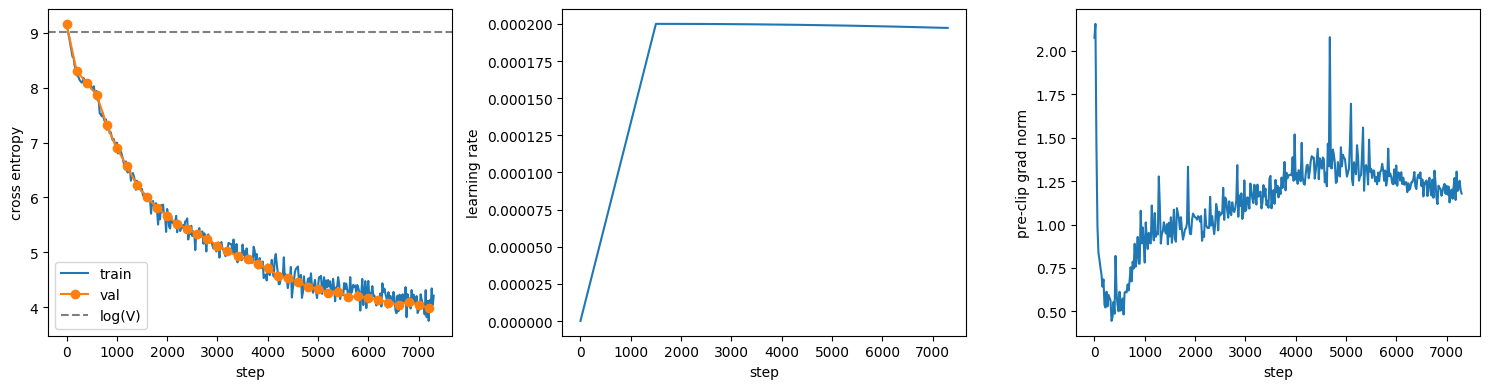

final train loss:     4.2102
final val loss:       3.9824
final val perplexity: 53.64


In [39]:
if tinyllm_30m_history is not None:
    plot_training_history(
        tinyllm_30m_history,
        baseline_loss=math.log(tinyllm_vocab_size),
    )

In [41]:
if tinyllm_30m_model is not None:
    show_samples(
        "TinyLLM 30M",
        tinyllm_30m_model,
        tinyllm_tokenizer,
        prompt="The best part about living in Florida is",
    )


TinyLLM 30M raw sample, escaped so control bytes do not wreck the notebook output
------------------------------------------------------------------------
The best part about living in Florida island, \u201cconverters\u201d, and therefore very well in the earth, making them a huge increase in tens of year.\u201d The other thing to all. Our above is the day\u2019s warmest day for endurance, compliment, or interrupts from this. (Thanks there the more of the images of much of the Monsteries) because they are much more invited. The advent is one of the old onions especially in resident fields and is worse to be the only land of those on lorders of half one. An art of their place is \u201cthe most unfoldest towns,\u201d which was just the fact that \u201cchallenges\u201d would always be a place in the super-image of his kindenly\u201d would actually have been wrote to take actors over their respective despairs.\nIn the mid-1940s, a float itcoe was born in New Zealand. During the wartime Kan

### Save TinyLLM 30M as `TinyLLM`

Run **only when the run looks done.** Publishes `artifacts/models/TinyLLM/` for the assistant-shaped tracks in Modules 13-15.


In [ ]:
if tinyllm_30m_model is not None and tinyllm_30m_history is not None:
    save_model_artifact(
        "TinyLLM",
        model=tinyllm_30m_model,
        model_config=tinyllm_30m_model_config,
        training_config=tinyllm_30m_trainer_config,
        tokenizer_artifact_name=tinyllm_tokenizer_name,
        source=f"g2c train slice ({tinyllm_train_max_chars:,} chars)",
        history=tinyllm_30m_history,
        seed=3,
        notes="Module 10 -- broader-corpus model on G2C corpus.",
        repo_root=repo_root,
    )
    print("saved TinyLLM")


In [ ]:
"Question: How does the TinyStories 5M validation curve compare with the TinyShakespeare curve?"
"Answer: "

"Question: If you ran the 30M model, did validation keep improving longer or overfit sooner?"
"Answer: "

"Question: What changed more visibly in samples: spelling, sentence shape, or story coherence?"
"Answer: "

"Question: If you ran TinyLLM 30M, how do its samples differ from StoryLM 30M trained with the same architecture? Where does the broader corpus help, and where does it hurt at this scale?"
"Answer: "


When complete, ask a coding agent to grade your Module 10 notebook. Partial work is fine: the agent should grade answered questions and implemented sections, then skip blank prompts.